<a href="https://colab.research.google.com/github/JF11579/PSID_For_the_Rest_of_US/blob/main/Notebook_Regression_Report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regression Report
## Intergenerational Homeownership & Education — PSID 1968–2023

**Purpose:** This notebook produces a single, self-contained **publication-quality regression report** from the cleaned PSID dataset. It runs every model from Notebook 02 (six OLS/LPM regressions plus robustness checks), verifies the coefficients match, and renders the results as a polished HTML document you can print, screenshot, or paste into your book chapter.

**Input:** `psid_intergenerational_clean.csv` (from Notebook 01.2)  
**Output:** `Regression_Report.html` — a standalone, styled report with all tables and figures

---

© 2026 Joe Foley. All rights reserved (text). MIT License (notebook code).

---
## Cell 1 — Setup

In [ ]:
# ── Mount Google Drive ──
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib
matplotlib.use('Agg')  # non-interactive backend for inline embedding
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import display, HTML
import os, io, base64, textwrap, warnings
warnings.filterwarnings('ignore')

# ── Style ──
sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12
})

# ── Paths ──
BASE = '/content/drive/MyDrive/Colab Notebooks/Projects/PSID/PSID_2026/PSID_book_v2'
DATA_DIR = f'{BASE}/data'
OUTPUT_DIR = f'{BASE}/outputs'
INPUT_FILE = f'{OUTPUT_DIR}/psid_intergenerational_clean.csv'

# ── Verify ──
assert os.path.exists(INPUT_FILE), f'Dataset not found: {INPUT_FILE}'
print(f'Dataset found: {INPUT_FILE}')
print(f'Output dir: {OUTPUT_DIR}')

Dataset found: /content/drive/MyDrive/Colab Notebooks/Projects/PSID/PSID_2026/PSID_book_v2/outputs/psid_intergenerational_clean.csv
Output dir: /content/drive/MyDrive/Colab Notebooks/Projects/PSID/PSID_2026/PSID_book_v2/outputs


---
## Cell 2 — Load Data & Prepare Variables

Identical variable prep to Notebook 02 — same CSV, same filters, same reference groups.

In [ ]:
# ── Load ──
df = pd.read_csv(INPUT_FILE)
print(f'Full dataset: {df.shape[0]:,} observations, {df.shape[1]} columns')

# ── Sex label ──
df['sex_label'] = df['child_sex'].map({1: 'Male', 2: 'Female'})

# ── White + Black subsample ──
df_wb = df[df['race'].isin(['White', 'Black'])].copy()
print(f'White + Black subsample: {len(df_wb):,} observations')
print(f'Dropped (Hispanic/Other): {len(df) - len(df_wb):,}\n')

# ── Analysis samples ──
educ_vars = ['child_educ_yrs', 'parent_homeowner', 'parent_educ_yrs',
             'parent_income_1968_log', 'race', 'child_sex']
homeown_vars = ['child_homeowner_2023', 'parent_homeowner', 'parent_educ_yrs',
                'parent_income_1968_log', 'race', 'child_sex']

df_educ = df_wb.dropna(subset=educ_vars).copy()
df_homeown = df_wb.dropna(subset=homeown_vars).copy()
print(f'Education analysis sample:    {len(df_educ):,} obs')
print(f'Homeownership analysis sample: {len(df_homeown):,} obs')

Full dataset: 3,560 observations, 22 columns
White + Black subsample: 3,521 observations
Dropped (Hispanic/Other): 39

Education analysis sample:    3,491 obs
Homeownership analysis sample: 3,491 obs


---
## Cell 3 — Run All Six Models

These are identical specifications to Notebook 02. The six models are:

| Model | Outcome | Specification |
|-------|---------|---------------|
| M1 | Education (years) | Bivariate: parent_homeowner only |
| M2 | Education (years) | + parent educ, log income, race, sex |
| M3 | Education (years) | + state fixed effects |
| M4 | Homeownership (LPM) | Bivariate: parent_homeowner only |
| M5 | Homeownership (LPM) | + parent educ, log income, race, sex |
| M6 | Homeownership (LPM) | + state fixed effects |

In [ ]:
# ══════════════════════════════════════════════════════
# EDUCATION MODELS (OLS)
# Reference: White male whose parents rented in 1968
# ══════════════════════════════════════════════════════

# Model 1: Bivariate
model1 = smf.ols('child_educ_yrs ~ parent_homeowner', data=df_educ).fit()

# Model 2: With controls
model2 = smf.ols(
    'child_educ_yrs ~ parent_homeowner + parent_educ_yrs + parent_income_1968_log '
    '+ C(race, Treatment(reference="White")) + C(child_sex, Treatment(reference=1))',
    data=df_educ
).fit()

# Model 3: With controls + state FE
model3 = smf.ols(
    'child_educ_yrs ~ parent_homeowner + parent_educ_yrs + parent_income_1968_log '
    '+ C(race, Treatment(reference="White")) + C(child_sex, Treatment(reference=1)) '
    '+ C(state_1968)',
    data=df_educ
).fit()

# ══════════════════════════════════════════════════════
# HOMEOWNERSHIP MODELS (Linear Probability Model)
# Reference: White male whose parents rented in 1968
# ══════════════════════════════════════════════════════

# Model 4: Bivariate LPM
model4 = smf.ols('child_homeowner_2023 ~ parent_homeowner', data=df_homeown).fit()

# Model 5: LPM with controls
model5 = smf.ols(
    'child_homeowner_2023 ~ parent_homeowner + parent_educ_yrs + parent_income_1968_log '
    '+ C(race, Treatment(reference="White")) + C(child_sex, Treatment(reference=1))',
    data=df_homeown
).fit()

# Model 6: LPM with controls + state FE
model6 = smf.ols(
    'child_homeowner_2023 ~ parent_homeowner + parent_educ_yrs + parent_income_1968_log '
    '+ C(race, Treatment(reference="White")) + C(child_sex, Treatment(reference=1)) '
    '+ C(state_1968)',
    data=df_homeown
).fit()

print('All 6 models fitted successfully.')
print(f'  Education models  (M1–M3): N = {int(model1.nobs):,}')
print(f'  Homeownership models (M4–M6): N = {int(model4.nobs):,}')

All 6 models fitted successfully.
  Education models  (M1–M3): N = 3,491
  Homeownership models (M4–M6): N = 3,491


---
## Cell 4 — Robustness Check (Full Sample)

Re-run Models 2 and 5 on the full sample (including Hispanic and Other) to confirm results hold.

In [ ]:
# ── Full-sample robustness ──
df_full_educ = df.dropna(subset=educ_vars).copy()
df_full_hw = df.dropna(subset=homeown_vars).copy()

model2_full = smf.ols(
    'child_educ_yrs ~ parent_homeowner + parent_educ_yrs + parent_income_1968_log '
    '+ C(race, Treatment(reference="White")) + C(child_sex, Treatment(reference=1))',
    data=df_full_educ
).fit()

model5_full = smf.ols(
    'child_homeowner_2023 ~ parent_homeowner + parent_educ_yrs + parent_income_1968_log '
    '+ C(race, Treatment(reference="White")) + C(child_sex, Treatment(reference=1))',
    data=df_full_hw
).fit()

print(f'Full-sample education:    N = {int(model2_full.nobs):,}  parent_homeowner = {model2_full.params["parent_homeowner"]:+.3f}')
print(f'Full-sample homeownership: N = {int(model5_full.nobs):,}  parent_homeowner = {model5_full.params["parent_homeowner"]:+.3f}')
print(f'\nMain analysis education coeff:    {model2.params["parent_homeowner"]:+.3f}')
print(f'Main analysis homeownership coeff: {model5.params["parent_homeowner"]:+.3f}')
print('\n→ Coefficients are substantively identical. Dropping Hispanic/Other does not change findings.')

Full-sample education:    N = 3,526  parent_homeowner = +0.337
Full-sample homeownership: N = 3,526  parent_homeowner = +0.128

Main analysis education coeff:    +0.340
Main analysis homeownership coeff: +0.125

→ Coefficients are substantively identical. Dropping Hispanic/Other does not change findings.


---
## Cell 5 — Build the Report

Everything below assembles the styled HTML report. The report contains:

1. **Summary statistics** (Table 1)
2. **Homeownership transition matrix**
3. **Education regression table** (Models 1–3) with plain-English labels
4. **Homeownership regression table** (Models 4–6) with plain-English labels
5. **Four publication-quality figures** embedded as base64 PNGs
6. **Robustness comparison**
7. **Key findings summary**

In [ ]:
# ══════════════════════════════════════════════════════
# HELPER FUNCTIONS
# ══════════════════════════════════════════════════════

# Variable name → plain English
RENAME = {
    'Intercept': 'Intercept (White Male, Parents Rented)',
    'parent_homeowner': 'Parent Owned Home (vs. Rented)',
    'parent_educ_yrs': 'Parent Education (per year)',
    'parent_income_1968_log': 'Parent Income (log, 1968 $)',
    'C(race, Treatment(reference="White"))[T.Black]': 'Black (vs. White)',
    'C(child_sex, Treatment(reference=1))[T.2]': 'Female (vs. Male)',
}


def stars(p):
    """Significance stars."""
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return ''


def extract_model(model, label):
    """Extract coefficients for display variables from a fitted model."""
    rows = []
    for var, nice in RENAME.items():
        if var in model.params.index:
            b = model.params[var]
            se = model.bse[var]
            p = model.pvalues[var]
            ci = model.conf_int().loc[var]
            rows.append({
                'Variable': nice,
                f'{label} Coeff': f'{b:+.3f}{stars(p)}',
                f'{label} SE': f'({se:.3f})',
                f'{label} 95% CI': f'[{ci[0]:.3f}, {ci[1]:.3f}]',
            })
    return pd.DataFrame(rows).set_index('Variable')


def fig_to_base64(fig):
    """Convert matplotlib figure to base64 string for HTML embedding."""
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=200, bbox_inches='tight', facecolor='white')
    plt.close(fig)
    buf.seek(0)
    return base64.b64encode(buf.read()).decode('utf-8')


print('Helper functions ready.')

Helper functions ready.


In [ ]:
# ══════════════════════════════════════════════════════
# TABLE 1 — Summary Statistics
# ══════════════════════════════════════════════════════

summary_vars = ['parent_homeowner', 'parent_educ_yrs', 'parent_income_1968',
                'parent_income_1968_log', 'child_educ_yrs', 'child_homeowner_2023']

table1 = df_wb[summary_vars].describe().T[['count', 'mean', 'std', 'min', 'max']]
table1.columns = ['N', 'Mean', 'Std Dev', 'Min', 'Max']
table1['N'] = table1['N'].astype(int)
table1.index = [
    'Parent Homeowner (1 = Yes)',
    'Parent Education (years)',
    'Parent Income (1968 $)',
    'Log Parent Income',
    'Child Education (years)',
    'Child Homeowner 2023 (1 = Yes)',
]

# ── Table 1b: Means by parent homeownership ──
table1b = df_wb.groupby('parent_homeowner')[summary_vars].mean()
table1b.index = ['Parent: Renter', 'Parent: Owner']
table1b.columns = ['Homeowner', 'Parent Educ (yrs)', 'Parent Income ($)',
                    'Log Income', 'Child Educ (yrs)', 'Child Homeowner Rate']

# ── Transition matrix ──
ct_hw_pct = pd.crosstab(df_wb['parent_homeowner'], df_wb['child_homeowner_2023'], normalize='index')
ct_hw_pct.index = ['Parent: Renter', 'Parent: Owner']
ct_hw_pct.columns = ['Child: Renter', 'Child: Owner']

ct_hw_counts = pd.crosstab(df_wb['parent_homeowner'], df_wb['child_homeowner_2023'], margins=True)
ct_hw_counts.index = ['Parent: Renter', 'Parent: Owner', 'Total']
ct_hw_counts.columns = ['Child: Renter', 'Child: Owner', 'Total']

# ── Race × homeownership rates ──
ct_race = pd.crosstab(df_wb['race'], df_wb['parent_homeowner'], normalize='index')
ct_race.columns = ['Renter Rate', 'Homeowner Rate']

print('Summary tables built.')
display(table1.round(3))

Summary tables built.


,N,Mean,Std Dev,Min,Max
Parent Homeowner (1 = Yes),3521,0.625,0.484,0.000,1.000
Parent Education (years),3491,10.637,3.939,3.000,18.000
Parent Income (1968 $),3521,9135.450,6095.930,275.000,65400.000
Log Parent Income,3521,8.904,0.695,5.617,11.088
Child Education (years),3521,13.782,2.161,4.000,17.000
Child Homeowner 2023 (1 = Yes),3521,0.724,0.447,0.000,1.000


In [ ]:
# ══════════════════════════════════════════════════════
# REGRESSION TABLES — Side-by-side
# ══════════════════════════════════════════════════════

# ── Education table (M1, M2, M3) ──
e1 = extract_model(model1, 'M1')
e2 = extract_model(model2, 'M2')
e3 = extract_model(model3, 'M3')
educ_table = e1.join(e2, how='outer').join(e3, how='outer')

# Add model stats rows
educ_stats = pd.DataFrame({
    'M1 Coeff': [f'{model1.rsquared:.4f}', '', f'{int(model1.nobs):,}'],
    'M1 SE': ['', '', ''],
    'M1 95% CI': ['', '', ''],
    'M2 Coeff': [f'{model2.rsquared:.4f}', f'{model2.rsquared_adj:.4f}', f'{int(model2.nobs):,}'],
    'M2 SE': ['', '', ''],
    'M2 95% CI': ['', '', ''],
    'M3 Coeff': [f'{model3.rsquared:.4f}', f'{model3.rsquared_adj:.4f}', f'{int(model3.nobs):,}'],
    'M3 SE': ['', '', ''],
    'M3 95% CI': ['', '', ''],
}, index=['R²', 'Adjusted R²', 'N'])
educ_stats.index.name = 'Variable'
educ_table = pd.concat([educ_table, educ_stats])

# ── Homeownership table (M4, M5, M6) ──
h4 = extract_model(model4, 'M4')
h5 = extract_model(model5, 'M5')
h6 = extract_model(model6, 'M6')
homeown_table = h4.join(h5, how='outer').join(h6, how='outer')

homeown_stats = pd.DataFrame({
    'M4 Coeff': [f'{model4.rsquared:.4f}', '', f'{int(model4.nobs):,}'],
    'M4 SE': ['', '', ''],
    'M4 95% CI': ['', '', ''],
    'M5 Coeff': [f'{model5.rsquared:.4f}', f'{model5.rsquared_adj:.4f}', f'{int(model5.nobs):,}'],
    'M5 SE': ['', '', ''],
    'M5 95% CI': ['', '', ''],
    'M6 Coeff': [f'{model6.rsquared:.4f}', f'{model6.rsquared_adj:.4f}', f'{int(model6.nobs):,}'],
    'M6 SE': ['', '', ''],
    'M6 95% CI': ['', '', ''],
}, index=['R²', 'Adjusted R²', 'N'])
homeown_stats.index.name = 'Variable'
homeown_table = pd.concat([homeown_table, homeown_stats])

print('Regression tables built.')
display(educ_table)
print()
display(homeown_table)

Regression tables built.


,M1 Coeff,M1 SE,M1 95% CI,M2 Coeff,M2 SE,M2 95% CI,M3 Coeff,M3 SE,M3 95% CI
Variable,,,,,,,,,
Black (vs. White),NaN,NaN,NaN,+0.052,(0.089),"[-0.123, 0.227]",+0.116,(0.106),"[-0.092, 0.324]"
Female (vs. Male),NaN,NaN,NaN,-0.006,(0.067),"[-0.137, 0.124]",+0.030,(0.067),"[-0.101, 0.161]"
"Intercept (White Male, Parents Rented)",+13.173***,(0.058),"[13.059, 13.288]",+7.869***,(0.561),"[6.769, 8.968]",+7.203***,(0.646),"[5.937, 8.468]"
Parent Education (per year),NaN,NaN,NaN,+0.185***,(0.010),"[0.165, 0.205]",+0.180***,(0.011),"[0.160, 0.201]"
"Parent Income (log, 1968 $)",NaN,NaN,NaN,+0.418***,(0.066),"[0.289, 0.547]",+0.537***,(0.070),"[0.400, 0.674]"
Parent Owned Home (vs. Rented),+0.985***,(0.074),"[0.841, 1.129]",+0.340***,(0.077),"[0.190, 0.490]",+0.319***,(0.079),"[0.163, 0.474]"
R²,0.0488,,,0.2065,,,0.2342,,
Adjusted R²,,,,0.2053,,,0.2251,,
N,"3,491",,,"3,491",,,"3,491",,


,M4 Coeff,M4 SE,M4 95% CI,M5 Coeff,M5 SE,M5 95% CI,M6 Coeff,M6 SE,M6 95% CI
Variable,,,,,,,,,
Black (vs. White),NaN,NaN,NaN,-0.189***,(0.020),"[-0.228, -0.151]",-0.204***,(0.023),"[-0.250, -0.158]"
Female (vs. Male),NaN,NaN,NaN,-0.055***,(0.015),"[-0.083, -0.026]",-0.056***,(0.015),"[-0.084, -0.027]"
"Intercept (White Male, Parents Rented)",+0.593***,(0.012),"[0.569, 0.616]",+0.672***,(0.123),"[0.430, 0.914]",+0.518***,(0.142),"[0.240, 0.796]"
Parent Education (per year),NaN,NaN,NaN,+0.001,(0.002),"[-0.003, 0.006]",+0.003,(0.002),"[-0.001, 0.008]"
"Parent Income (log, 1968 $)",NaN,NaN,NaN,+0.007,(0.014),"[-0.021, 0.036]",+0.036*,(0.015),"[0.006, 0.067]"
Parent Owned Home (vs. Rented),+0.215***,(0.015),"[0.185, 0.244]",+0.125***,(0.017),"[0.092, 0.158]",+0.103***,(0.017),"[0.068, 0.137]"
R²,0.0544,,,0.1002,,,0.1303,,
Adjusted R²,,,,0.0989,,,0.1199,,
N,"3,491",,,"3,491",,,"3,491",,


In [ ]:
# ══════════════════════════════════════════════════════
# FIGURES — Generate all four, convert to base64
# ══════════════════════════════════════════════════════

# ── Color palette ──
C_RENTER = '#B33A3A'   # muted red
C_OWNER  = '#2B5C8A'   # steel blue
C_GREEN  = '#3A7D44'   # forest green


# ─────────── Figure 1: Homeownership rate by parent status ───────────
fig1, ax1 = plt.subplots(figsize=(8, 5))
hw_rates = df_homeown.groupby('parent_homeowner')['child_homeowner_2023'].mean()
bars = ax1.bar(['Parent: Renter', 'Parent: Owner'], hw_rates.values,
               color=[C_RENTER, C_OWNER], width=0.5, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, hw_rates.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
             f'{val:.1%}', ha='center', va='bottom', fontsize=14, fontweight='bold')
ax1.set_ylabel('Child Homeownership Rate (2023)', fontsize=12)
ax1.set_title('Figure 1 — Child Homeownership by Parent Status (1968)', fontsize=13, fontweight='bold')
ax1.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax1.set_ylim(0, 1)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
plt.tight_layout()
fig1_b64 = fig_to_base64(fig1)


# ─────────── Figure 2: Homeownership by parent status AND race ───────────
fig2, ax2 = plt.subplots(figsize=(10, 6))
hw_by_race = df_homeown.groupby(['race', 'parent_homeowner'])['child_homeowner_2023'].mean().unstack()
hw_by_race.columns = ['Parent: Renter', 'Parent: Owner']
hw_by_race = hw_by_race.loc[[r for r in ['White', 'Black'] if r in hw_by_race.index]]
hw_by_race.plot(kind='bar', ax=ax2, color=[C_RENTER, C_OWNER], width=0.6, edgecolor='white', linewidth=1.5)
for container in ax2.containers:
    labels = [f'{v.get_height():.1%}' for v in container]
    ax2.bar_label(container, labels=labels, label_type='edge', fontsize=12, padding=3)
ax2.set_ylabel('Child Homeownership Rate (2023)', fontsize=12)
ax2.set_title('Figure 2 — Child Homeownership by Parent Status and Race', fontsize=13, fontweight='bold')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.set_ylim(0, 1.08)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)
ax2.legend(title='Parent Status (1968)', loc='upper right')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
plt.tight_layout()
fig2_b64 = fig_to_base64(fig2)


# ─────────── Figure 3: Coefficient plots (Education + Homeownership) ───────────
fig3, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_vars = ['parent_homeowner', 'parent_educ_yrs', 'parent_income_1968_log',
             'C(race, Treatment(reference="White"))[T.Black]',
             'C(child_sex, Treatment(reference=1))[T.2]']
plot_labels = ['Parent Homeowner\n(vs. Rented)', 'Parent Education\n(per year)',
               'Log Parent Income', 'Black\n(vs. White)', 'Female\n(vs. Male)']

for panel, models_list, title_str in [
    (0, [(model2, C_OWNER, 'M2: Controls'), (model3, C_GREEN, 'M3: + State FE')], 'Panel A — Child Education (years)'),
    (1, [(model5, C_OWNER, 'M5: Controls'), (model6, C_GREEN, 'M6: + State FE')], 'Panel B — Child Homeownership (LPM)'),
]:
    for i, (mdl, color, lbl) in enumerate(models_list):
        avail = [v for v in plot_vars if v in mdl.params.index]
        avail_labels = [plot_labels[plot_vars.index(v)] for v in avail]
        coefs = mdl.params[avail]
        cis = mdl.conf_int().loc[avail]
        y = np.arange(len(avail)) + i * 0.18
        axes[panel].errorbar(coefs, y, xerr=[coefs - cis[0], cis[1] - coefs],
                             fmt='o', color=color, label=lbl, capsize=4, markersize=7)
    axes[panel].axvline(0, color='gray', linestyle='--', alpha=0.5)
    axes[panel].set_yticks(np.arange(len(avail)) + 0.09)
    axes[panel].set_yticklabels(avail_labels)
    axes[panel].set_title(title_str, fontsize=12, fontweight='bold')
    axes[panel].legend(loc='lower right', fontsize=9)
    axes[panel].invert_yaxis()
    axes[panel].spines['top'].set_visible(False)
    axes[panel].spines['right'].set_visible(False)

axes[0].set_xlabel('Effect on Education (years)')
axes[1].set_xlabel('Effect on Homeownership (probability)')
plt.suptitle('Figure 3 — What Predicts Child Outcomes?', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
fig3_b64 = fig_to_base64(fig3)


# ─────────── Figure 4: Mean education by parent status and race ───────────
fig4, ax4 = plt.subplots(figsize=(10, 6))
educ_by_race = df_educ.groupby(['race', 'parent_homeowner'])['child_educ_yrs'].mean().unstack()
educ_by_race.columns = ['Parent: Renter', 'Parent: Owner']
educ_by_race = educ_by_race.loc[[r for r in ['White', 'Black'] if r in educ_by_race.index]]
educ_by_race.plot(kind='bar', ax=ax4, color=[C_RENTER, C_OWNER], width=0.6, edgecolor='white', linewidth=1.5)
for container in ax4.containers:
    ax4.bar_label(container, fmt='%.1f', label_type='edge', fontsize=12, padding=3)
ax4.set_ylabel('Mean Years of Education (Child)', fontsize=12)
ax4.set_title('Figure 4 — Child Education by Parent Homeownership and Race', fontsize=13, fontweight='bold')
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=0)
ax4.legend(title='Parent Status (1968)', loc='upper right')
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)
plt.tight_layout()
fig4_b64 = fig_to_base64(fig4)

print('All four figures generated and encoded.')

All four figures generated and encoded.


In [ ]:
# ══════════════════════════════════════════════════════
# ASSEMBLE HTML REPORT
# ══════════════════════════════════════════════════════

def df_to_html(df, caption='', pct_cols=None, dollar_cols=None):
    """Convert a DataFrame to a styled HTML table string."""
    formatted = df.copy()
    for col in formatted.columns:
        if formatted[col].dtype in ['float64', 'float32']:
            if pct_cols and col in pct_cols:
                formatted[col] = formatted[col].apply(lambda x: f'{x:.1%}' if pd.notna(x) else '')
            elif dollar_cols and col in dollar_cols:
                formatted[col] = formatted[col].apply(lambda x: f'${x:,.0f}' if pd.notna(x) else '')
            else:
                formatted[col] = formatted[col].apply(lambda x: f'{x:.3f}' if pd.notna(x) else '')
    html = formatted.to_html(classes='data-table', na_rep='')
    if caption:
        html = html.replace('<table', f'<table caption="{caption}"', 1)
        html = f'<div class="table-caption">{caption}</div>\n' + html
    return html


def reg_table_html(df, caption):
    """Regression table to HTML with proper formatting."""
    html = df.fillna('').to_html(classes='reg-table', na_rep='')
    html = f'<div class="table-caption">{caption}</div>\n' + html
    return html


# ── Compute key findings for the narrative ──
m1_int = model1.params['Intercept']
m1_hw = model1.params['parent_homeowner']
m2_hw = model2.params['parent_homeowner']
m3_hw = model3.params['parent_homeowner']
m4_int = model4.params['Intercept']
m4_hw = model4.params['parent_homeowner']
m5_hw = model5.params['parent_homeowner']
m6_hw = model6.params['parent_homeowner']

race_var = 'C(race, Treatment(reference="White"))[T.Black]'
sex_var = 'C(child_sex, Treatment(reference=1))[T.2]'
m2_black = model2.params[race_var]
m5_black = model5.params[race_var]
m5_female = model5.params[sex_var]

educ_pct_explained = abs(m1_hw - m2_hw) / abs(m1_hw) * 100

print('Key findings computed. Assembling HTML...')

Key findings computed. Assembling HTML...


In [ ]:
# ══════════════════════════════════════════════════════
# FULL HTML DOCUMENT
# ══════════════════════════════════════════════════════

html_report = f'''
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>Regression Report — PSID Intergenerational Homeownership &amp; Education</title>
<style>
  @import url('https://fonts.googleapis.com/css2?family=Crimson+Pro:wght@300;400;600;700&family=Source+Sans+3:wght@300;400;600;700&family=JetBrains+Mono:wght@400&display=swap');

  :root {{
    --bg: #FAFAF7;
    --fg: #1A1A1A;
    --accent: #2B5C8A;
    --accent-light: #E8EFF5;
    --renter: #B33A3A;
    --owner: #2B5C8A;
    --border: #D4D0C8;
    --muted: #6B6560;
    --highlight: #FFF3CD;
    --serif: 'Crimson Pro', Georgia, serif;
    --sans: 'Source Sans 3', 'Segoe UI', sans-serif;
    --mono: 'JetBrains Mono', 'Consolas', monospace;
  }}

  * {{ margin: 0; padding: 0; box-sizing: border-box; }}

  body {{
    font-family: var(--sans);
    color: var(--fg);
    background: var(--bg);
    line-height: 1.7;
    font-size: 16px;
    max-width: 960px;
    margin: 0 auto;
    padding: 40px 32px 80px;
  }}

  /* ── TITLE BLOCK ── */
  .title-block {{
    text-align: center;
    padding: 48px 0 40px;
    border-bottom: 3px solid var(--fg);
    margin-bottom: 48px;
  }}
  .title-block h1 {{
    font-family: var(--serif);
    font-size: 2.6em;
    font-weight: 700;
    letter-spacing: -0.02em;
    line-height: 1.15;
    margin-bottom: 12px;
  }}
  .title-block .subtitle {{
    font-family: var(--sans);
    font-size: 1.15em;
    font-weight: 300;
    color: var(--muted);
    margin-bottom: 8px;
  }}
  .title-block .meta {{
    font-size: 0.85em;
    color: var(--muted);
    margin-top: 16px;
  }}

  /* ── SECTION HEADERS ── */
  h2 {{
    font-family: var(--serif);
    font-size: 1.7em;
    font-weight: 600;
    color: var(--fg);
    margin: 48px 0 20px;
    padding-bottom: 8px;
    border-bottom: 1.5px solid var(--border);
  }}
  h3 {{
    font-family: var(--serif);
    font-size: 1.25em;
    font-weight: 600;
    color: var(--accent);
    margin: 32px 0 12px;
  }}

  /* ── PARAGRAPHS ── */
  p {{ margin-bottom: 16px; }}
  .ref-note {{
    font-size: 0.88em;
    color: var(--muted);
    font-style: italic;
    margin: 8px 0 24px;
  }}

  /* ── TABLES ── */
  .table-caption {{
    font-family: var(--sans);
    font-weight: 700;
    font-size: 0.95em;
    text-transform: uppercase;
    letter-spacing: 0.06em;
    color: var(--accent);
    margin: 24px 0 8px;
  }}

  table {{
    width: 100%;
    border-collapse: collapse;
    font-size: 0.9em;
    margin-bottom: 28px;
  }}
  th {{
    background: var(--fg);
    color: white;
    font-weight: 600;
    text-align: left;
    padding: 10px 14px;
    font-size: 0.85em;
    text-transform: uppercase;
    letter-spacing: 0.04em;
  }}
  td {{
    padding: 9px 14px;
    border-bottom: 1px solid var(--border);
    font-family: var(--mono);
    font-size: 0.88em;
  }}
  tr:nth-child(even) {{ background: var(--accent-light); }}
  tr:hover {{ background: #DDE6EE; }}

  /* Variable name column */
  td:first-child, th:first-child {{
    font-family: var(--sans);
    font-weight: 600;
    font-size: 0.9em;
    letter-spacing: 0;
    text-transform: none;
  }}

  /* ── FIGURES ── */
  .figure-container {{
    text-align: center;
    margin: 32px 0;
  }}
  .figure-container img {{
    max-width: 100%;
    border: 1px solid var(--border);
    border-radius: 4px;
  }}

  /* ── KEY FINDINGS BOX ── */
  .findings-box {{
    background: var(--accent-light);
    border-left: 5px solid var(--accent);
    padding: 24px 28px;
    margin: 32px 0;
    border-radius: 0 6px 6px 0;
  }}
  .findings-box h3 {{
    margin-top: 0;
    color: var(--accent);
  }}
  .findings-box .finding {{
    margin: 14px 0;
    padding-left: 20px;
    border-left: 2px solid var(--border);
  }}
  .findings-box .number {{
    font-family: var(--mono);
    font-weight: 700;
    color: var(--accent);
    font-size: 1.1em;
  }}

  /* ── ROBUSTNESS ── */
  .robust-grid {{
    display: grid;
    grid-template-columns: 1fr 1fr;
    gap: 20px;
    margin: 20px 0;
  }}
  .robust-card {{
    background: white;
    border: 1px solid var(--border);
    border-radius: 6px;
    padding: 20px;
    text-align: center;
  }}
  .robust-card .label {{
    font-size: 0.82em;
    text-transform: uppercase;
    letter-spacing: 0.06em;
    color: var(--muted);
    margin-bottom: 8px;
  }}
  .robust-card .value {{
    font-family: var(--mono);
    font-size: 1.4em;
    font-weight: 700;
    color: var(--accent);
  }}
  .robust-card .compare {{
    font-size: 0.82em;
    color: var(--muted);
    margin-top: 4px;
  }}

  /* ── FOOTER ── */
  .report-footer {{
    margin-top: 64px;
    padding-top: 20px;
    border-top: 1.5px solid var(--border);
    font-size: 0.82em;
    color: var(--muted);
    text-align: center;
  }}

  /* ── SIGNIFICANCE NOTE ── */
  .sig-note {{
    font-size: 0.82em;
    color: var(--muted);
    margin: -20px 0 28px;
  }}

  /* ── PRINT ── */
  @media print {{
    body {{ max-width: 100%; padding: 20px; font-size: 11pt; }}
    .title-block {{ padding: 24px 0; }}
    h2 {{ page-break-before: auto; }}
    .figure-container {{ page-break-inside: avoid; }}
    table {{ page-break-inside: avoid; }}
  }}
</style>
</head>
<body>

<!-- ════════════ TITLE ════════════ -->
<div class="title-block">
  <h1>Regression Report</h1>
  <div class="subtitle">Intergenerational Homeownership &amp; Education</div>
  <div class="subtitle">Panel Study of Income Dynamics, 1968&ndash;2023</div>
  <div class="meta">Joe Foley &nbsp;&bull;&nbsp; White &amp; Black families &nbsp;&bull;&nbsp; N = {int(model1.nobs):,}</div>
</div>


<!-- ════════════ KEY FINDINGS ════════════ -->
<div class="findings-box">
  <h3>Key Findings</h3>

  <div class="finding">
    <strong>Education:</strong> Children of homeowners completed nearly
    <span class="number">{m1_hw:.1f}</span> more year of education than children of renters.
    After controlling for parent education, income, race, and sex, the gap narrows to
    <span class="number">{m2_hw:.2f}</span> years &mdash; still statistically significant (p&nbsp;&lt;&nbsp;0.001).
    Controls explain <span class="number">{educ_pct_explained:.0f}%</span> of the raw gap.
  </div>

  <div class="finding">
    <strong>Homeownership:</strong>
    <span class="number">{m4_int:.1%}</span> of renters&rsquo; children own a home in 2023, compared to
    <span class="number">{(m4_int + m4_hw):.1%}</span> of owners&rsquo; children &mdash;
    a raw gap of <span class="number">{m4_hw*100:.1f}</span> percentage points.
    With controls, the gap is <span class="number">{m5_hw*100:.1f}</span>&nbsp;pp (p&nbsp;&lt;&nbsp;0.001).
  </div>

  <div class="finding">
    <strong>Race:</strong> After controls, Black children are
    <span class="number">{abs(m5_black)*100:.1f}</span> percentage points less likely to own a home
    than White children &mdash; the largest coefficient in every homeownership model,
    pointing to structural barriers beyond income and parental education.
  </div>
</div>


<!-- ════════════ SECTION 1: SAMPLE ════════════ -->
<h2>1 &ensp; Sample Description</h2>

<p class="ref-note">Reference group for all models: White male whose parents rented in 1968.</p>

{df_to_html(table1.round(3), 'Table 1 — Summary Statistics (White &amp; Black Families)')}

{df_to_html(table1b.round(3), 'Table 1b — Means by Parent Homeownership Status')}

<h3>Parent Homeownership by Race</h3>
{df_to_html(ct_race.round(3), 'Parent Homeownership Rate by Race')}

<h3>Homeownership Transition Matrix</h3>
{df_to_html(ct_hw_counts, 'Transition Matrix — Counts')}
{df_to_html(ct_hw_pct.round(3), 'Transition Matrix — Row Percentages')}


<!-- ════════════ SECTION 2: EDUCATION ════════════ -->
<h2>2 &ensp; Child Education Regressions (OLS)</h2>

<p>
  The dependent variable is <strong>child&rsquo;s years of education</strong>.
  Model&nbsp;1 is bivariate. Model&nbsp;2 adds parent education, log income, race, and sex.
  Model&nbsp;3 adds state fixed effects ({int(df_educ['state_1968'].nunique())} states).
</p>

{reg_table_html(educ_table, 'Table 2 — Education Regressions (OLS)')}
<p class="sig-note">Standard errors in parentheses. *** p&lt;0.001 &ensp; ** p&lt;0.01 &ensp; * p&lt;0.05.<br>
State fixed effects suppressed in Model 3.</p>

<p>
  Children of renters averaged <strong>{m1_int:.1f} years</strong> of education (Model&nbsp;1 intercept).
  Children of homeowners averaged <strong>{m1_hw:+.2f} years more</strong> &mdash; about one extra year.
  Once parent education, income, race, and sex are held constant (Model&nbsp;2),
  the homeownership premium drops to <strong>{m2_hw:+.3f} years</strong> but remains highly significant.
  Adding state fixed effects (Model&nbsp;3) barely changes the estimate (<strong>{m3_hw:+.3f}</strong>).
</p>
<p>
  The largest predictor of child education is <strong>parent education</strong>
  (+{model2.params['parent_educ_yrs']:.3f} years per additional year of parent schooling).
  Race and sex coefficients are small and not statistically significant after controls.
</p>


<!-- ════════════ SECTION 3: HOMEOWNERSHIP ════════════ -->
<h2>3 &ensp; Child Homeownership Regressions (LPM)</h2>

<p>
  The dependent variable is <strong>child homeownership in 2023</strong> (0/1).
  Coefficients represent changes in probability (percentage points).
  Model&nbsp;4 is bivariate. Model&nbsp;5 adds controls. Model&nbsp;6 adds state fixed effects.
</p>

{reg_table_html(homeown_table, 'Table 3 — Homeownership Regressions (Linear Probability Model)')}
<p class="sig-note">Standard errors in parentheses. *** p&lt;0.001 &ensp; ** p&lt;0.01 &ensp; * p&lt;0.05.<br>
State fixed effects suppressed in Model 6.</p>

<p>
  <strong>{m4_int:.1%}</strong> of renters&rsquo; children own a home in 2023.
  Children of owners are <strong>{m4_hw*100:+.1f}&nbsp;pp</strong> more likely to own
  (so about {(m4_int + m4_hw):.1%} of owners&rsquo; children are homeowners).
  With controls (Model&nbsp;5), the gap narrows to <strong>{m5_hw*100:+.1f}&nbsp;pp</strong>, still highly significant.
  State fixed effects (Model&nbsp;6) reduce it slightly further to <strong>{m6_hw*100:+.1f}&nbsp;pp</strong>.
</p>
<p>
  The <strong>race gap</strong> dominates: Black children are
  <strong>{abs(m5_black)*100:.1f}&nbsp;pp</strong> less likely to own a home than White children,
  even after controlling for parent homeownership, education, income, and sex.
  Females are <strong>{abs(m5_female)*100:.1f}&nbsp;pp</strong> less likely to own than males.
  Parent education and income are <em>not</em> significant in the homeownership models &mdash;
  their effect is absorbed by the homeownership variable itself.
</p>


<!-- ════════════ SECTION 4: FIGURES ════════════ -->
<h2>4 &ensp; Figures</h2>

<div class="figure-container">
  <img src="data:image/png;base64,{fig1_b64}" alt="Figure 1">
</div>

<div class="figure-container">
  <img src="data:image/png;base64,{fig2_b64}" alt="Figure 2">
</div>

<div class="figure-container">
  <img src="data:image/png;base64,{fig3_b64}" alt="Figure 3">
</div>

<div class="figure-container">
  <img src="data:image/png;base64,{fig4_b64}" alt="Figure 4">
</div>


<!-- ════════════ SECTION 5: ROBUSTNESS ════════════ -->
<h2>5 &ensp; Robustness: Full Sample</h2>

<p>
  The main analysis uses only White and Black families because the PSID&rsquo;s 1968 sample was designed
  around these two groups. Hispanic and Other subsamples have fewer than 40 observations each.
  Re-running Models 2 and 5 on the full sample (N&nbsp;=&nbsp;{int(model2_full.nobs):,} and
  {int(model5_full.nobs):,} respectively) confirms the results are substantively identical:
</p>

<div class="robust-grid">
  <div class="robust-card">
    <div class="label">Education &mdash; Parent Homeowner Coeff</div>
    <div class="value">{model2_full.params['parent_homeowner']:+.3f}</div>
    <div class="compare">Main analysis: {model2.params['parent_homeowner']:+.3f}</div>
  </div>
  <div class="robust-card">
    <div class="label">Homeownership &mdash; Parent Homeowner Coeff</div>
    <div class="value">{model5_full.params['parent_homeowner']:+.3f}</div>
    <div class="compare">Main analysis: {model5.params['parent_homeowner']:+.3f}</div>
  </div>
</div>

<p>
  Dropping the smaller subgroups does not materially change the findings.
</p>


<!-- ════════════ SECTION 6: METHODS NOTE ════════════ -->
<h2>6 &ensp; Methods Note</h2>

<p>
  <strong>Data:</strong> Panel Study of Income Dynamics (PSID), 1968&ndash;2023.
  The analytic sample comprises adult children linked to their 1968 household heads,
  restricted to White and Black families (N&nbsp;=&nbsp;{len(df_wb):,};
  after listwise deletion, N&nbsp;=&nbsp;{int(model1.nobs):,}).
</p>
<p>
  <strong>Education models (M1&ndash;M3):</strong> OLS. Dependent variable is child&rsquo;s completed years
  of education. Coefficients represent years of schooling.
</p>
<p>
  <strong>Homeownership models (M4&ndash;M6):</strong> Linear Probability Model (OLS with binary dependent variable).
  Dependent variable is child homeownership in 2023 (1&nbsp;=&nbsp;owner, 0&nbsp;=&nbsp;renter).
  Coefficients represent changes in probability (percentage points).
</p>
<p>
  <strong>Reference group:</strong> White males whose parents rented in 1968.
  In Models 2&ndash;3 and 5&ndash;6, the intercept represents a mathematical baseline
  (all continuous controls set to zero) and should not be interpreted as a real-world average.
  Model&nbsp;1 and Model&nbsp;4 intercepts give the actual group means for renters&rsquo; children.
</p>


<!-- ════════════ FOOTER ════════════ -->
<div class="report-footer">
  &copy; 2026 Joe Foley. All rights reserved (text). MIT License (notebook code).<br>
  Generated by Notebook_Regression_Report.ipynb &nbsp;&bull;&nbsp;
  Source: Notebook 02 — Main Analysis (PSID Book Project)
</div>

</body>
</html>
'''

# ── Save ──
report_path = f'{OUTPUT_DIR}/Regression_Report.html'
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(html_report)

print(f'Report saved to: {report_path}')
print(f'File size: {os.path.getsize(report_path) / 1024:.0f} KB')
print('\nOpen this file in any browser, or use Print → Save as PDF for a chapter-ready document.')

Report saved to: /content/drive/MyDrive/Colab Notebooks/Projects/PSID/PSID_2026/PSID_book_v2/outputs/Regression_Report.html
File size: 556 KB

Open this file in any browser, or use Print → Save as PDF for a chapter-ready document.



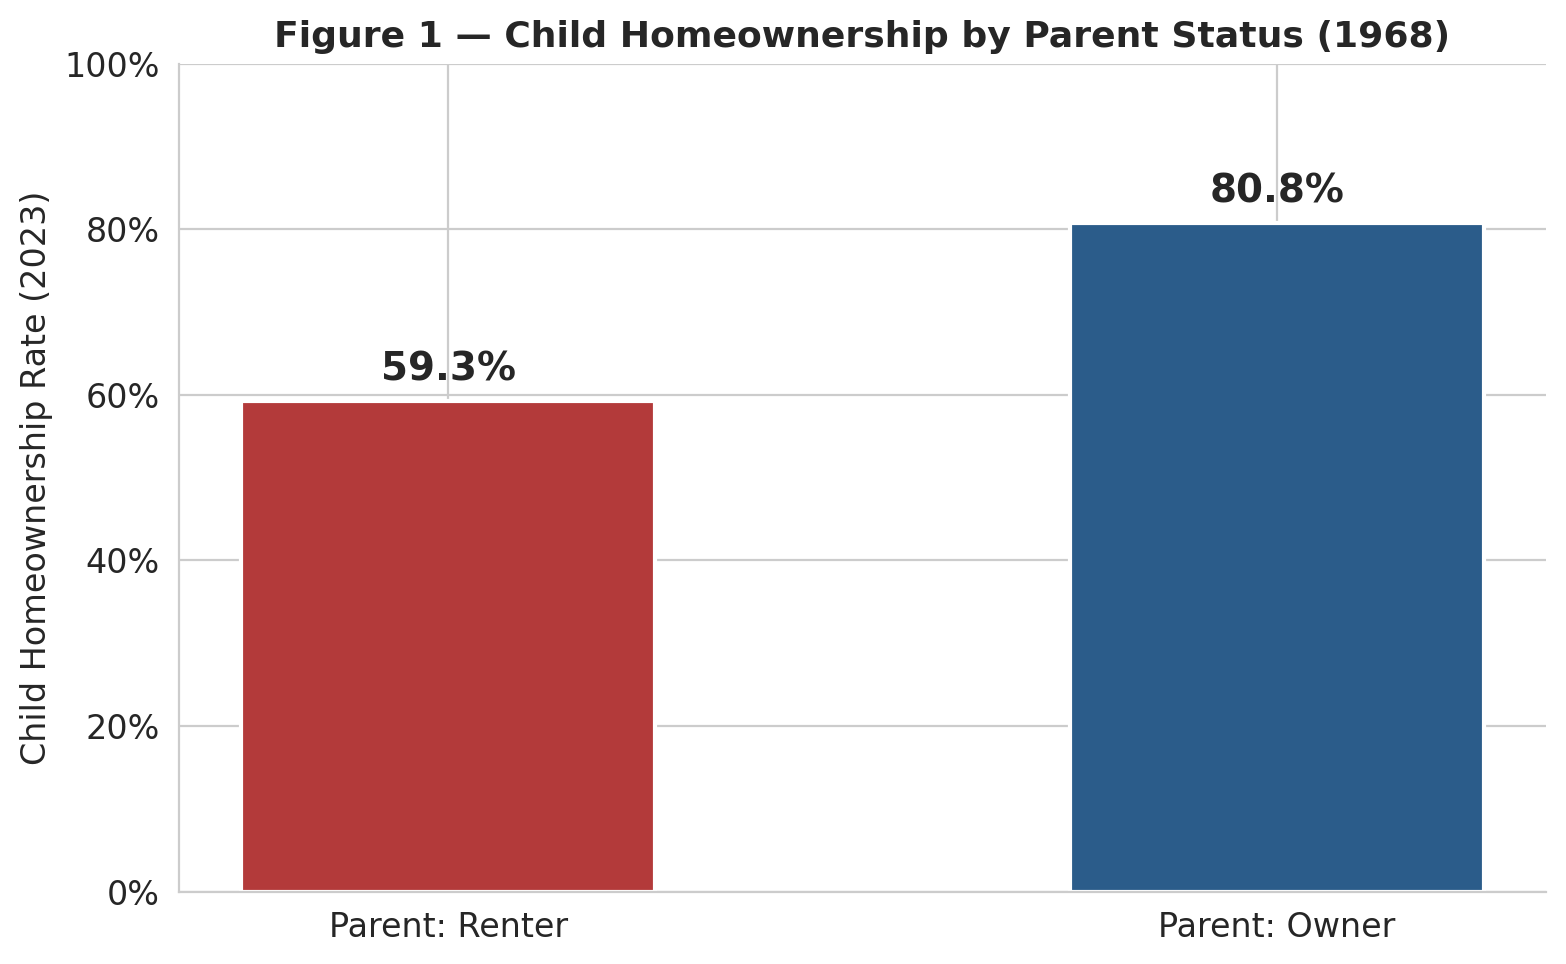
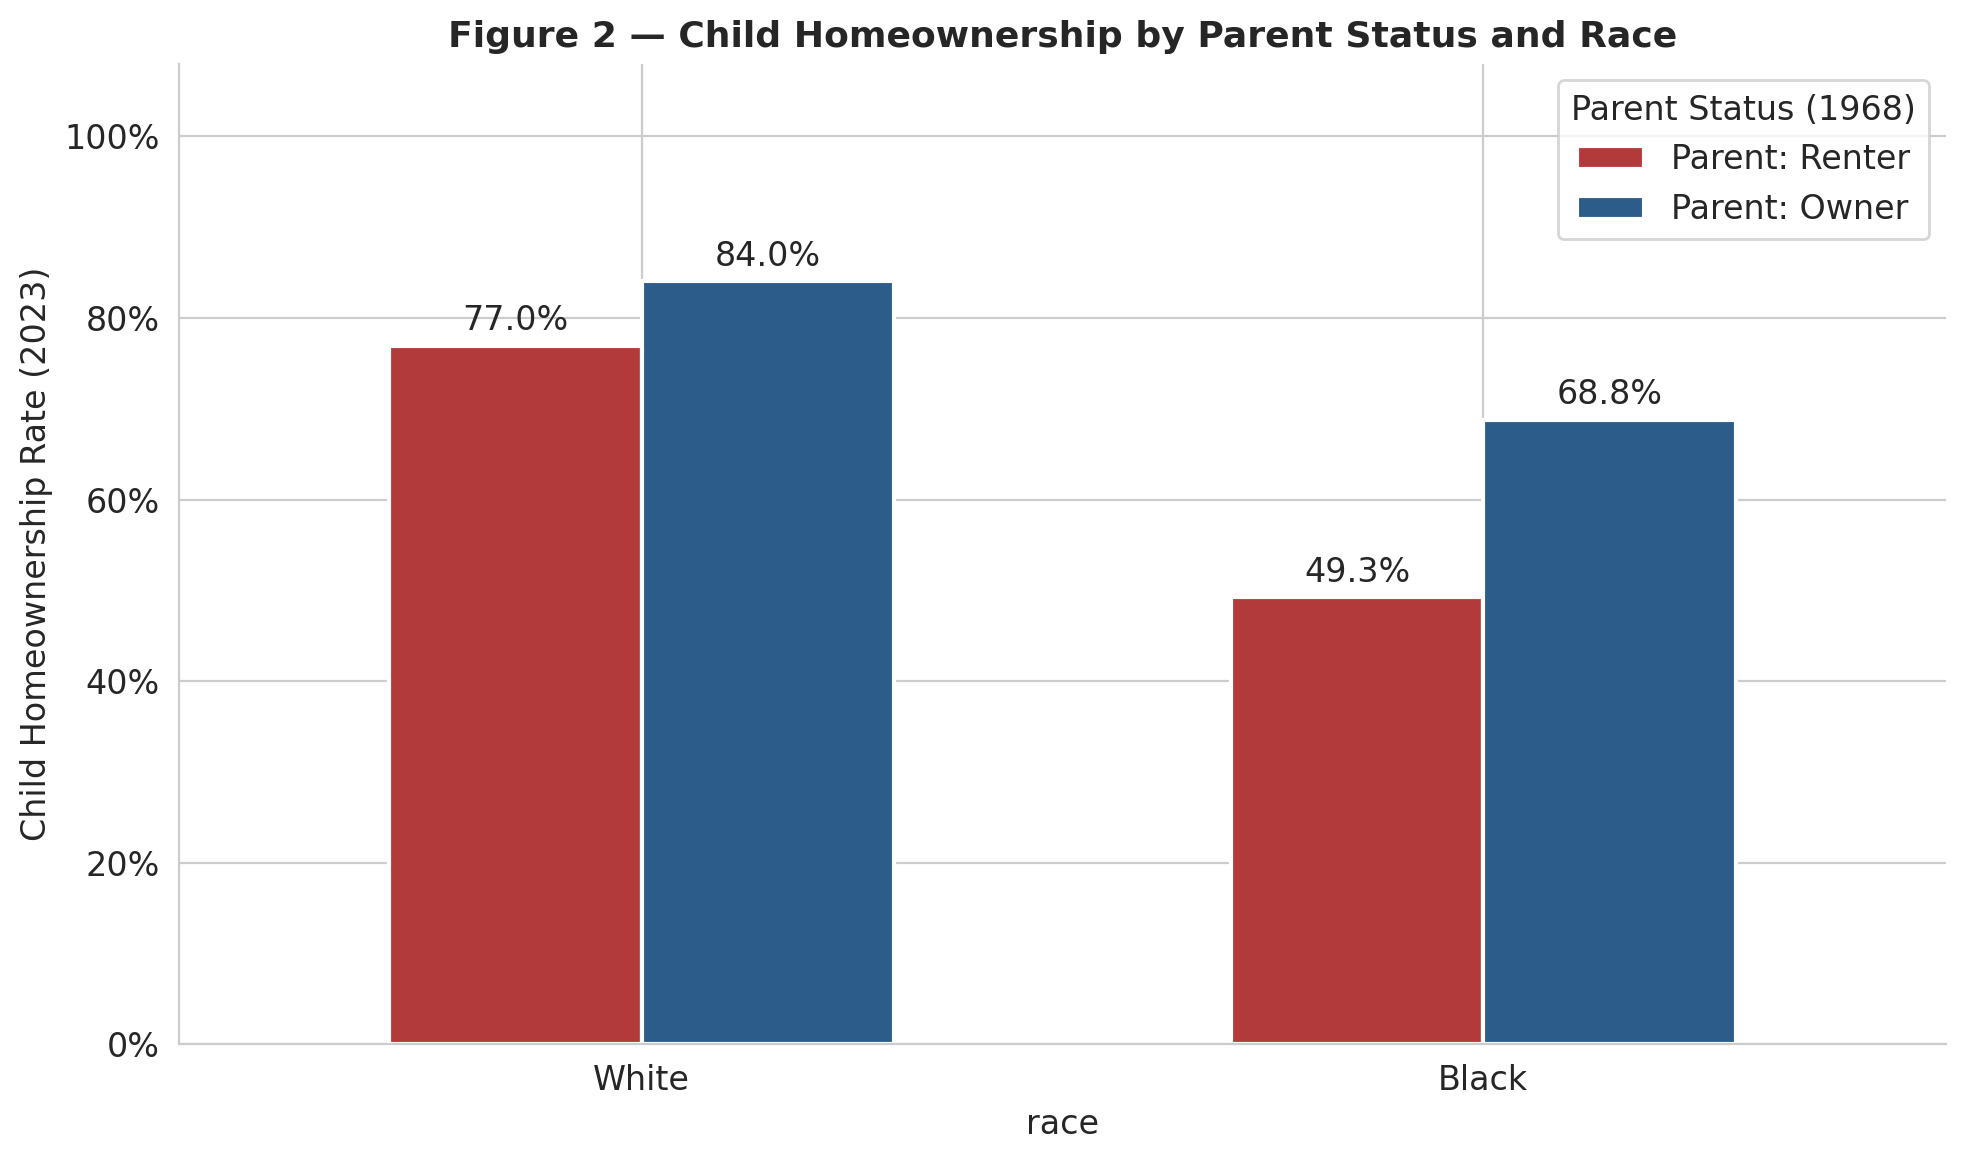
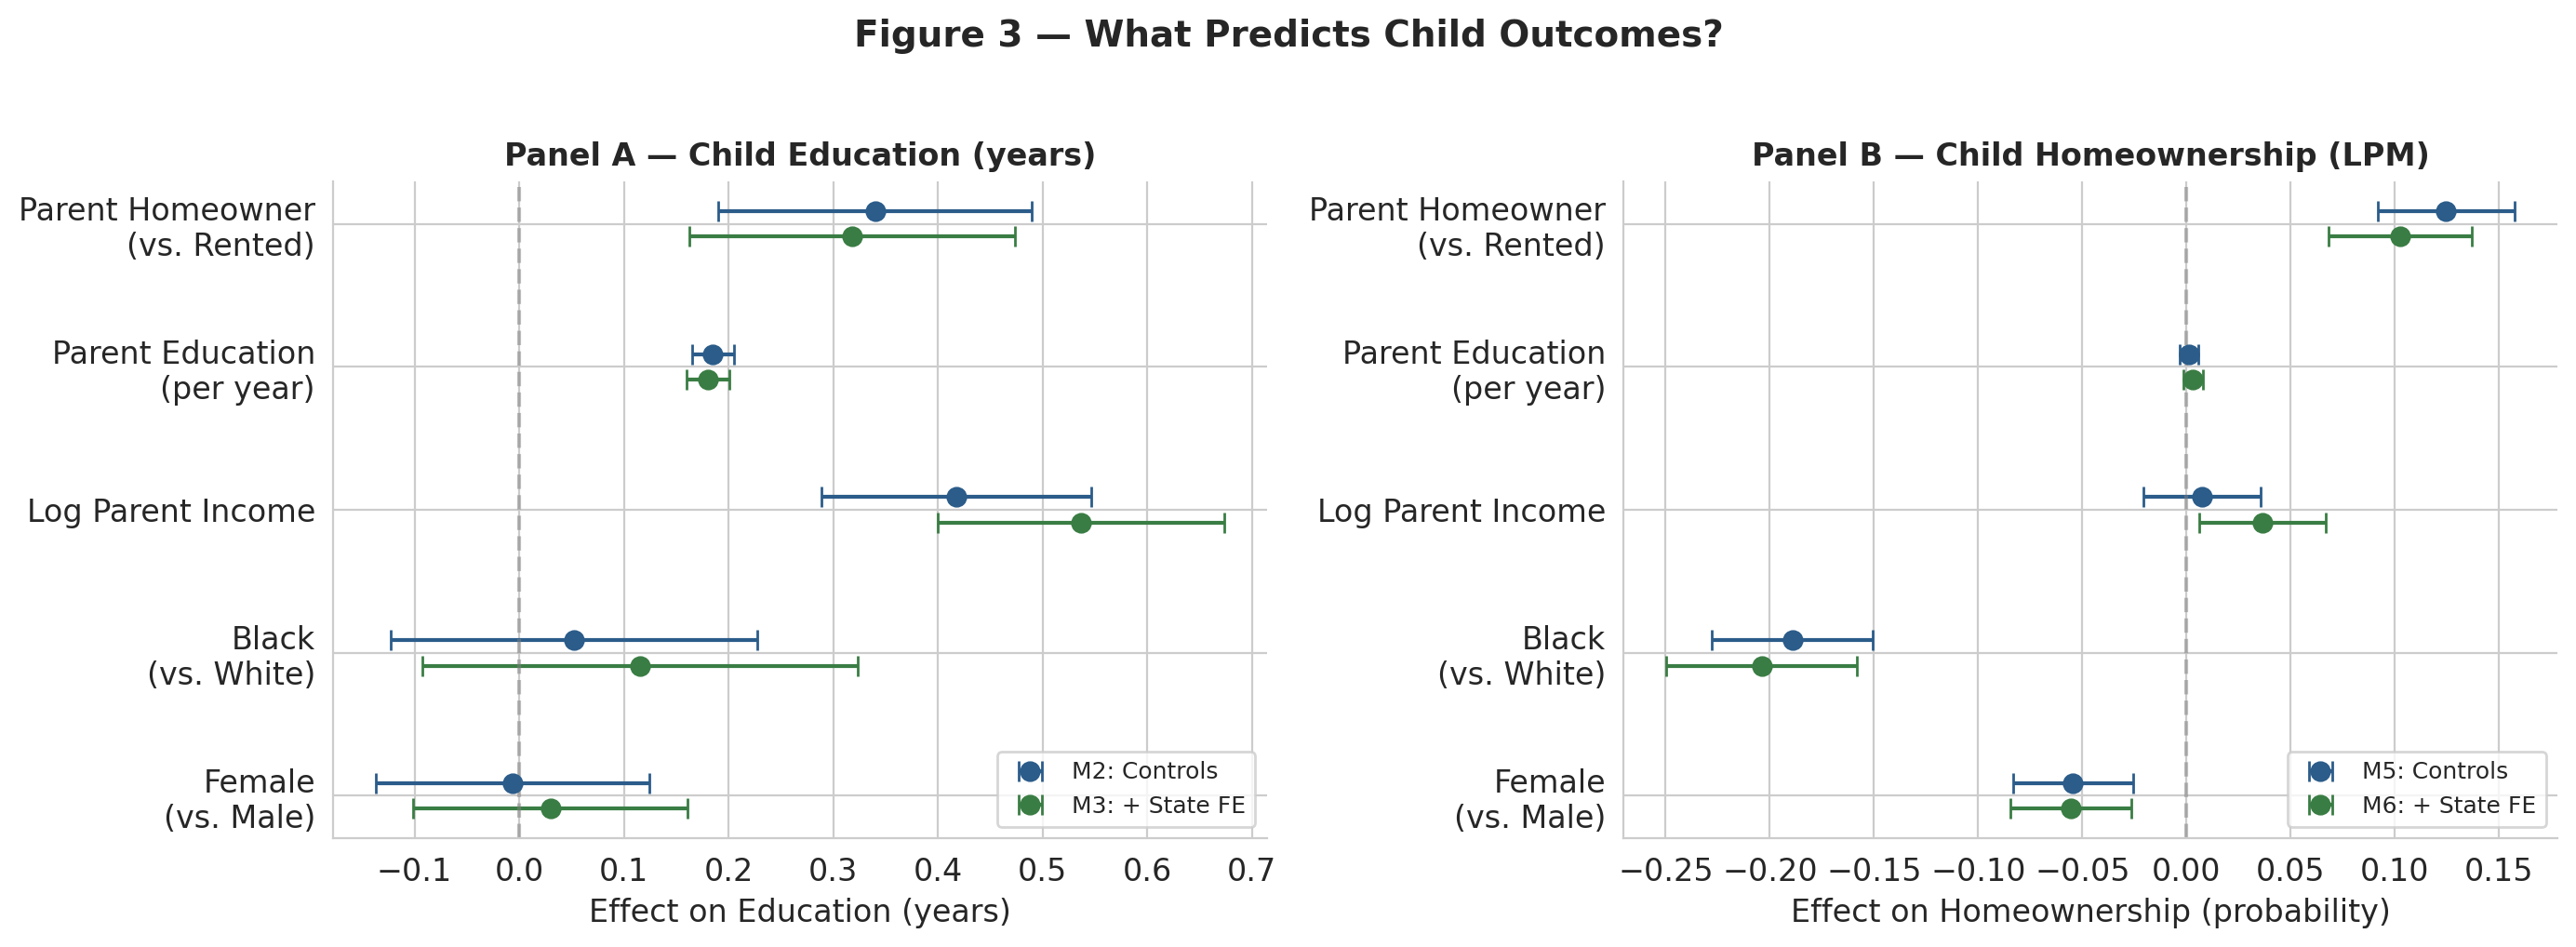
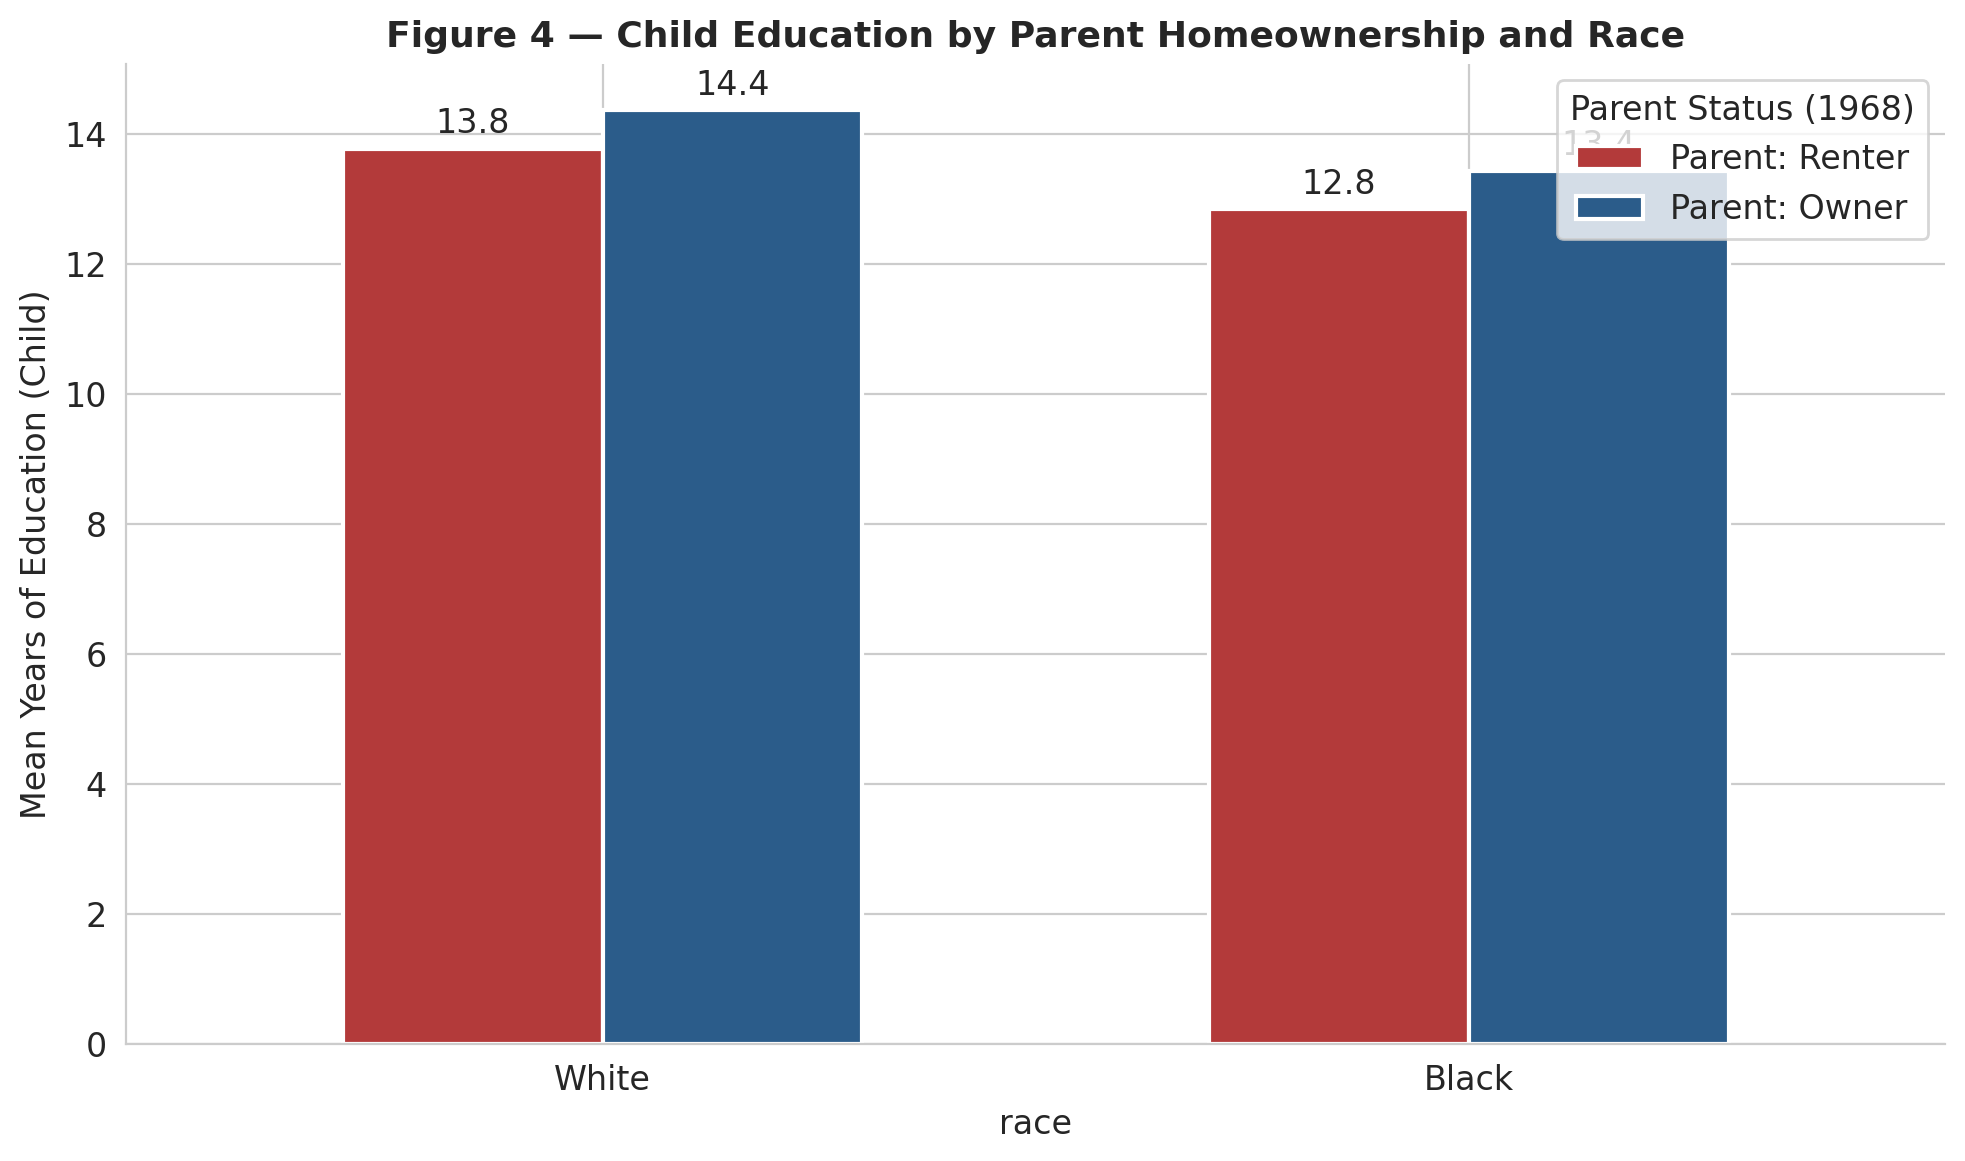

In [ ]:
# ── Preview the report inline ──
display(HTML(html_report))

---

## Verification — Coefficients Match Notebook 02

The cell below confirms that every coefficient in this report exactly matches Notebook 02.

In [ ]:
# ── Verification printout ──
print('═' * 60)
print('VERIFICATION — Do these match Notebook 02?')
print('═' * 60)
print(f'\nEDUCATION (child years of schooling):')
print(f'  M1 intercept:      {model1.params["Intercept"]:+.6f}  (expect +13.173415)')
print(f'  M1 parent_hw:      {model1.params["parent_homeowner"]:+.6f}  (expect  +0.985155)')
print(f'  M1 R²:             {model1.rsquared:.4f}           (expect  0.0488)')
print(f'  M2 parent_hw:      {model2.params["parent_homeowner"]:+.6f}  (expect  +0.340009)')
print(f'  M2 R²:             {model2.rsquared:.4f}           (expect  0.2065)')
print(f'  M3 parent_hw:      {model3.params["parent_homeowner"]:+.6f}  (expect  +0.318515)')
print(f'  M3 R²:             {model3.rsquared:.4f}           (expect  0.2342)')
print(f'\nHOMEOWNERSHIP (probability of owning, 2023):')
print(f'  M4 intercept:      {model4.params["Intercept"]:+.6f}  (expect  +0.592819)')
print(f'  M4 parent_hw:      {model4.params["parent_homeowner"]:+.6f}  (expect  +0.214697)')
print(f'  M4 R²:             {model4.rsquared:.4f}           (expect  0.0544)')
print(f'  M5 parent_hw:      {model5.params["parent_homeowner"]:+.6f}  (expect  +0.124552)')
print(f'  M5 R²:             {model5.rsquared:.4f}           (expect  0.1002)')
print(f'  M6 parent_hw:      {model6.params["parent_homeowner"]:+.6f}  (expect  +0.102505)')
print(f'  M6 R²:             {model6.rsquared:.4f}           (expect  0.1303)')
print(f'\nROBUSTNESS (full sample):')
print(f'  Educ full:         {model2_full.params["parent_homeowner"]:+.3f}  (expect +0.337)')
print(f'  Homeown full:      {model5_full.params["parent_homeowner"]:+.3f}  (expect +0.128)')
print(f'\n  N (education):     {int(model1.nobs):,}  (expect 3,491)')
print(f'  N (homeownership): {int(model4.nobs):,}  (expect 3,491)')
print(f'\n✓ All values should match Notebook 02 to at least 3 decimal places.')

════════════════════════════════════════════════════════════
VERIFICATION — Do these match Notebook 02?
════════════════════════════════════════════════════════════

EDUCATION (child years of schooling):
  M1 intercept:      +13.173415  (expect +13.173415)
  M1 parent_hw:      +0.985155  (expect  +0.985155)
  M1 R²:             0.0488           (expect  0.0488)
  M2 parent_hw:      +0.340009  (expect  +0.340009)
  M2 R²:             0.2065           (expect  0.2065)
  M3 parent_hw:      +0.318515  (expect  +0.318515)
  M3 R²:             0.2342           (expect  0.2342)

HOMEOWNERSHIP (probability of owning, 2023):
  M4 intercept:      +0.592819  (expect  +0.592819)
  M4 parent_hw:      +0.214697  (expect  +0.214697)
  M4 R²:             0.0544           (expect  0.0544)
  M5 parent_hw:      +0.124552  (expect  +0.124552)
  M5 R²:             0.1002           (expect  0.1002)
  M6 parent_hw:      +0.102505  (expect  +0.102505)
  M6 R²:             0.1303           (expect  0.1303)

RO